# 📊 Sistema Inteligente de Análisis de Cartera

## 🎯 Objetivo
Analizar la cartera de clientes para identificar niveles de riesgo crediticio, optimizar la gestión de cobranza y apoyar la toma de decisiones financieras.

## 🧠 Problema
Las empresas necesitan identificar qué clientes representan mayor riesgo y dónde enfocar esfuerzos de cobro.

In [1]:
!pip install pandas numpy matplotlib seaborn plotly openpyxl

## 📁 Generación de datos
Se simula una base de datos de clientes con información financiera.

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "cliente_id": range(1, n+1),
    "edad": np.random.randint(18, 70, n),
    "ingreso_mensual": np.random.randint(800, 8000, n),
    "monto_credito": np.random.randint(500, 20000, n),
    "dias_mora": np.random.randint(0, 120, n),
})

df.head()

,cliente_id,edad,ingreso_mensual,monto_credito,dias_mora
0,1,56,4143,14624,38
1,2,69,6108,16782,98
2,3,46,4870,10988,17
3,4,32,5599,5740,58
4,5,60,2270,10953,105


## 🧹 Preparación de datos
Se clasifica la cartera según días de mora.

In [4]:
def estado_mora(dias):
    if dias == 0:
        return "Al día"
    elif dias <= 30:
        return "Mora leve"
    elif dias <= 60:
        return "Mora media"
    else:
        return "Mora alta"

df["estado"] = df["dias_mora"].apply(estado_mora)

## 📈 Indicadores clave

In [5]:
total_clientes = len(df)
total_cartera = df["monto_credito"].sum()
mora_promedio = df["dias_mora"].mean()
tasa_mora = len(df[df["dias_mora"] > 0]) / total_clientes * 100

print("TOTAL CLIENTES:", total_clientes)
print("TOTAL CARTERA:", total_cartera)
print("MORA PROMEDIO:", round(mora_promedio,2))
print("TASA DE MORA %:", round(tasa_mora,2))

TOTAL CLIENTES: 500
TOTAL CARTERA: 5058744
MORA PROMEDIO: 58.47
TASA DE MORA %: 99.8


## ⚠️ Clasificación de riesgo

In [ ]:
## ⚠️ Clasificación de riesgo

In [6]:
def riesgo(row):
    if row["dias_mora"] > 60:
        return "Alto riesgo"
    elif row["dias_mora"] > 30:
        return "Riesgo medio"
    else:
        return "Bajo riesgo"

df["riesgo"] = df.apply(riesgo, axis=1)

df["riesgo"].value_counts()

,count
riesgo,
Alto riesgo,239
Bajo riesgo,131
Riesgo medio,130


## 🎯 Priorización de cobranza
Se identifican clientes con mayor impacto financiero.

In [7]:
top_deuda = df.sort_values(by="monto_credito", ascending=False).head(10)
top_mora = df.sort_values(by="dias_mora", ascending=False).head(10)

top_deuda
top_mora

,cliente_id,edad,ingreso_mensual,monto_credito,dias_mora,estado,riesgo
25,26,50,5348,14123,119,Mora alta,Alto riesgo
317,318,55,3579,16034,119,Mora alta,Alto riesgo
78,79,27,3244,6122,119,Mora alta,Alto riesgo
159,160,66,5291,577,119,Mora alta,Alto riesgo
134,135,57,4752,19708,119,Mora alta,Alto riesgo
353,354,55,4800,15570,118,Mora alta,Alto riesgo
44,45,38,4530,18860,118,Mora alta,Alto riesgo
313,314,28,6120,7811,117,Mora alta,Alto riesgo
439,440,68,2980,12612,117,Mora alta,Alto riesgo
122,123,24,7606,509,116,Mora alta,Alto riesgo


## 📉 Concentración del riesgo

In [8]:
cartera_total = df["monto_credito"].sum()

cartera_mora_alta = df[df["estado"]=="Mora alta"]["monto_credito"].sum()

porcentaje_mora_alta = cartera_mora_alta / cartera_total * 100

print("Porcentaje cartera en mora alta:", round(porcentaje_mora_alta,2), "%")

Porcentaje cartera en mora alta: 48.4 %


## 📊 Visualización de datos

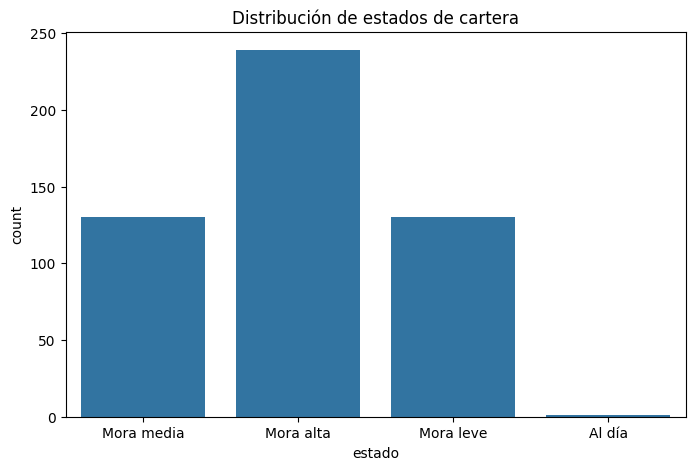

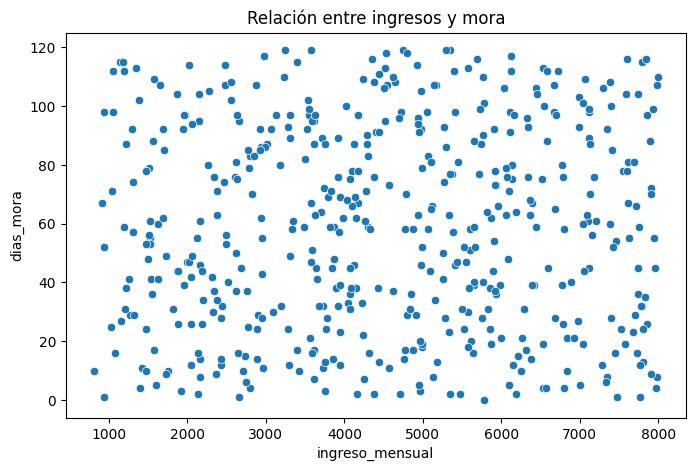

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="estado")
plt.title("Distribución de estados de cartera")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="ingreso_mensual", y="dias_mora")
plt.title("Relación entre ingresos y mora")
plt.show()

## 📊 Dashboard interactivo

In [10]:
import plotly.express as px

fig = px.pie(df, names='estado', title='Distribución de Cartera')
fig.show()

fig2 = px.histogram(df, x="dias_mora", nbins=20, title="Distribución de días de mora")
fig2.show()

## 📁 Exportación para BI

In [13]:
df.to_excel("reporte_cartera.xlsx", index=False)
df.to_csv("reporte_cartera.csv", index=False)

print("Reporte generado")

Reporte generado


In [14]:
df.to_excel("reporte_cartera.xlsx", index=False)

In [15]:
import os
os.listdir()

['.config', 'reporte_cartera.csv', 'reporte_cartera.xlsx', 'sample_data']

## 📌 Insights

- Se identificaron clientes con alto nivel de mora.
- Existe concentración de riesgo en ciertos segmentos.
- Los clientes con mayor deuda representan mayor impacto financiero.
- La mora está distribuida en diferentes niveles de riesgo.

## 🚀 Recomendaciones

- Priorizar clientes con mora alta.
- Enfocar gestión en clientes con mayor deuda.
- Crear estrategias de recuperación.
- Monitorear cartera constantemente.

## ✅ Conclusión

El análisis permitió identificar el estado de la cartera y los niveles de riesgo.

Este sistema facilita la toma de decisiones y la optimización de la gestión de cobranza.